🏁 Starting Point (Equal Allocation):
Node 1: 0.125
Node 2: 0.125
Node 3: 0.125
Node 4: 0.125
Node 5: 0.125
Node 6: 0.125
Node 7: 0.125
Node 8: 0.125

Initial Fitness: -0.0000

Iteration 1/40 | Best Fitness: -0.0125
Iteration 2/40 | Best Fitness: -0.0192
Iteration 3/40 | Best Fitness: -0.0141
Iteration 4/40 | Best Fitness: -0.0162
Iteration 5/40 | Best Fitness: -0.0158
Iteration 6/40 | Best Fitness: -0.0199
Iteration 7/40 | Best Fitness: -0.0158
Iteration 8/40 | Best Fitness: -0.0199
Iteration 9/40 | Best Fitness: -0.0241
Iteration 10/40 | Best Fitness: -0.0199
Iteration 11/40 | Best Fitness: -0.0158
Iteration 12/40 | Best Fitness: -0.0199
Iteration 13/40 | Best Fitness: -0.0158
Iteration 14/40 | Best Fitness: -0.0199
Iteration 15/40 | Best Fitness: -0.0158
Iteration 16/40 | Best Fitness: -0.0199
Iteration 17/40 | Best Fitness: -0.0158
Iteration 18/40 | Best Fitness: -0.0199
Iteration 19/40 | Best Fitness: -0.0138
Iteration 20/40 | Best Fitness: -0.0094
Iteration 21/40 | Best Fitness: -

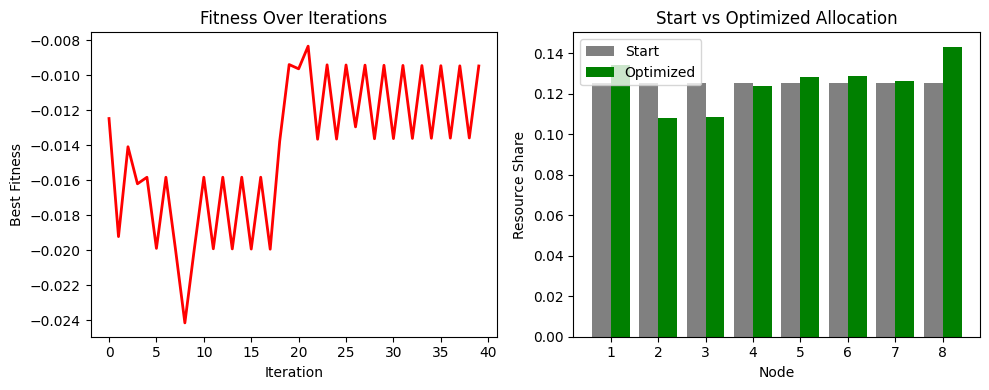

In [8]:
import numpy as np
from multiprocessing import Pool
import matplotlib.pyplot as plt

# ----------------------------
# Defined Inputs
# ----------------------------
num_nodes = 8             # Number of network nodes
total_resource = 1.0      # Total available resource
grid_size = (6, 6)        # PCA grid (6x6 = 36 cells)
iterations = 40           # Optimization iterations

# Network topology (simple ring)
neighbor_links = [(i, (i+1) % num_nodes) for i in range(num_nodes)]

# ----------------------------
# Objective Function
# ----------------------------
def fitness(solution):
    """
    Objective: Maximize - (imbalance + routing_penalty)
    """
    solution = np.clip(solution, 0, 1)
    solution = solution / np.sum(solution)  # Normalize so total = 1

    imbalance = np.var(solution)
    routing_penalty = sum(abs(solution[i] - solution[j]) for i, j in neighbor_links) / len(neighbor_links)

    return -(imbalance + routing_penalty)  # Maximize fitness

# ----------------------------
# Mutation (local variation)
# ----------------------------
def mutate(solution, rate=0.1):
    new_sol = solution.copy()
    idx = np.random.randint(len(solution))
    new_sol[idx] += np.random.uniform(-rate, rate)
    new_sol = np.clip(new_sol, 0, 1)
    new_sol /= np.sum(new_sol)
    return new_sol

# ----------------------------
# Local Evolution Function
# ----------------------------
def evolve_cell(args):
    i, j, grid, neighborhood = args
    rows, cols = grid.shape[:2]

    # Get neighbors (Von Neumann)
    neighbors = []
    for di, dj in neighborhood:
        ni, nj = (i + di) % rows, (j + dj) % cols
        neighbors.append(grid[ni, nj])

    # Compare with neighbors
    all_solutions = neighbors + [grid[i, j]]
    best_sol = max(all_solutions, key=fitness)

    # Apply mutation for diversity
    offspring = mutate(best_sol)
    return i, j, offspring

# ----------------------------
# Parallel Cellular Algorithm
# ----------------------------
def parallel_cellular_algorithm(grid_size=(6,6), sol_size=8, iterations=40, start_solution=None):
    grid = np.zeros((grid_size[0], grid_size[1], sol_size))

    # Initialize with small random variations around the starting point
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            grid[i, j] = start_solution + np.random.uniform(-0.05, 0.05, sol_size)
            grid[i, j] = np.clip(grid[i, j], 0, 1)
            grid[i, j] /= np.sum(grid[i, j])

    neighborhood = [(-1,0),(1,0),(0,-1),(0,1)]
    best_scores = []

    for it in range(iterations):
        args = [(i, j, grid, neighborhood) for i in range(grid.shape[0]) for j in range(grid.shape[1])]
        with Pool() as pool:
            results = pool.map(evolve_cell, args)

        for i, j, new_sol in results:
            grid[i, j] = new_sol

        # Record best fitness this iteration
        all_fitness = np.array([[fitness(grid[i, j]) for j in range(grid.shape[1])] for i in range(grid.shape[0])])
        best_scores.append(all_fitness.max())

        print(f"Iteration {it+1}/{iterations} | Best Fitness: {best_scores[-1]:.4f}")

    # Return best solution
    best_idx = np.unravel_index(np.argmax(all_fitness), all_fitness.shape)
    best_solution = grid[best_idx]

    return best_solution, best_scores

# ----------------------------
# Starting Point
# ----------------------------
start_solution = np.ones(num_nodes) * (total_resource / num_nodes)
print("🏁 Starting Point (Equal Allocation):")
for i, val in enumerate(start_solution):
    print(f"Node {i+1}: {val:.3f}")

start_fitness = fitness(start_solution)
print(f"\nInitial Fitness: {start_fitness:.4f}\n")

# ----------------------------
# Run the Algorithm
# ----------------------------
best_sol, history = parallel_cellular_algorithm(grid_size, num_nodes, iterations, start_solution)

# ----------------------------
# Results
# ----------------------------
print("\n✅ Final Optimized Resource Allocation:")
for i, val in enumerate(best_sol):
    print(f"Node {i+1}: {val:.3f}")

print(f"\nTotal Allocated Resource = {np.sum(best_sol):.3f}")
print(f"Final Fitness: {fitness(best_sol):.4f}")

# ----------------------------
# Visualization
# ----------------------------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history, 'r-', linewidth=2)
plt.title("Fitness Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Best Fitness")

plt.subplot(1,2,2)
x = np.arange(1, num_nodes+1)
plt.bar(x-0.2, start_solution, width=0.4, label='Start', color='gray')
plt.bar(x+0.2, best_sol, width=0.4, label='Optimized', color='green')
plt.xlabel("Node")
plt.ylabel("Resource Share")
plt.title("Start vs Optimized Allocation")
plt.legend()
plt.tight_layout()
plt.show()
